# 01 — Exploratory Data Analysis

> **Note:** This notebook explores **flow-level** CICIDS-2017 data. The anomaly detector pipeline (notebooks 02–05) operates on **spectral time-window features**, not raw scaled flows. For authoritative results use `python main.py`.

**Protocol (notebooks 02+):** Monday benign train → validation holdout from Monday tail + 50/50 attack val/test on Friday → `window_label_rule: majority`.

## 1. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import get_binary_labels
from nb_common import NotebookSettings, load_project_config, load_dataframe, setup_notebook

SETTINGS = NotebookSettings(use_sample=True, use_cache=True)
cfg = load_project_config(SETTINGS)
setup_notebook(cfg)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Config loaded; use_sample =', SETTINGS.use_sample)

Config loaded; use_sample = True


## 2. Load Dataset

In [2]:
df = load_dataframe(SETTINGS, cfg)
print(f'Shape: {df.shape}')
if 'day' in df.columns:
    print(df['day'].value_counts().to_string())
df.head()

Shape: (5000, 79)
day
Monday    5000


,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Timestamp,day
0,4.692681e+05,11.0,5.0,271.570252,788.023042,594.718293,77.772382,319.328499,29.544793,632.654905,...,12811.637022,290126.459705,37517.619607,4.621193e+06,274500.912563,2.262709e+05,63528.542674,BENIGN,2017-07-03 08:00:00,Monday
1,3.010121e+06,13.0,9.0,539.740002,385.442395,587.289345,87.304338,624.224819,18.359413,633.767907,...,10783.638349,227235.018463,93878.201179,2.074014e+05,300749.271889,1.249143e+05,19805.132469,BENIGN,2017-07-03 08:00:01,Monday
2,1.316746e+06,6.0,11.0,1109.880994,403.277814,908.921439,34.856481,740.738365,48.516311,1066.147919,...,1654.943760,288461.965918,18657.631053,2.010432e+06,154001.613072,7.933882e+05,464149.803171,BENIGN,2017-07-03 08:00:02,Monday
3,9.129426e+05,9.0,9.0,1391.164340,29.332662,602.779965,37.103804,374.391784,78.788755,870.662050,...,8455.112450,1460.893917,378825.025041,3.426676e+06,46566.090183,4.202742e+06,477248.251780,BENIGN,2017-07-03 08:00:03,Monday
4,1.696249e+05,12.0,8.0,1201.621602,135.143928,1017.600655,82.878158,350.907341,117.568333,1159.777799,...,316.909577,210878.735233,32023.089414,4.626838e+05,30266.881651,2.742916e+06,212187.498766,BENIGN,2017-07-03 08:00:04,Monday


## 3. Label Distribution

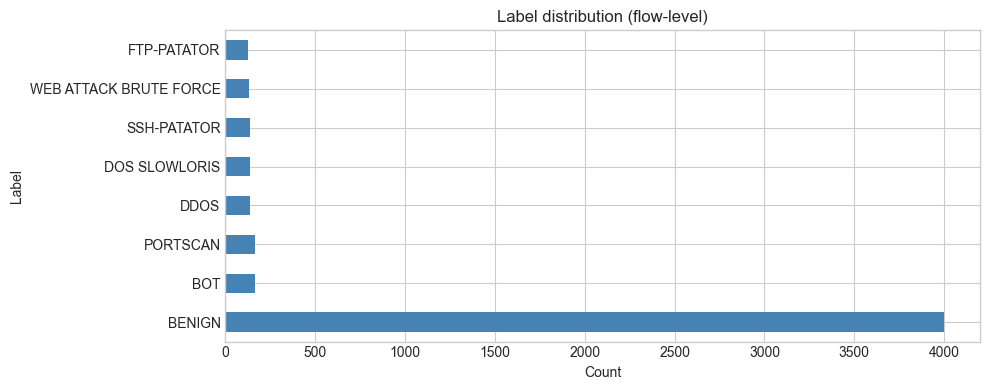

Label
BENIGN                    4000
BOT                        167
PORTSCAN                   162
DDOS                       139
DOS SLOWLORIS              139
SSH-PATATOR                137
WEB ATTACK BRUTE FORCE     131
FTP-PATATOR                125


In [3]:
if 'Label' in df.columns:
    counts = df['Label'].value_counts()
    fig, ax = plt.subplots(figsize=(10, 4))
    counts.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title('Label distribution (flow-level)')
    ax.set_xlabel('Count')
    plt.tight_layout()
    plt.show()
    print(counts.to_string())
else:
    print('No Label column — sample mode may use binary_label only')

## 4. Missing Values & Data Quality

In [4]:
numeric = df.select_dtypes(include=[np.number])
missing_pct = numeric.isna().mean().sort_values(ascending=False)
high_missing = missing_pct[missing_pct > 0.05]
print(f'Columns with >5% missing: {len(high_missing)}')
if len(high_missing):
    display(high_missing.head(10))

Columns with >5% missing: 0


## 5. Feature Distributions (sample columns)

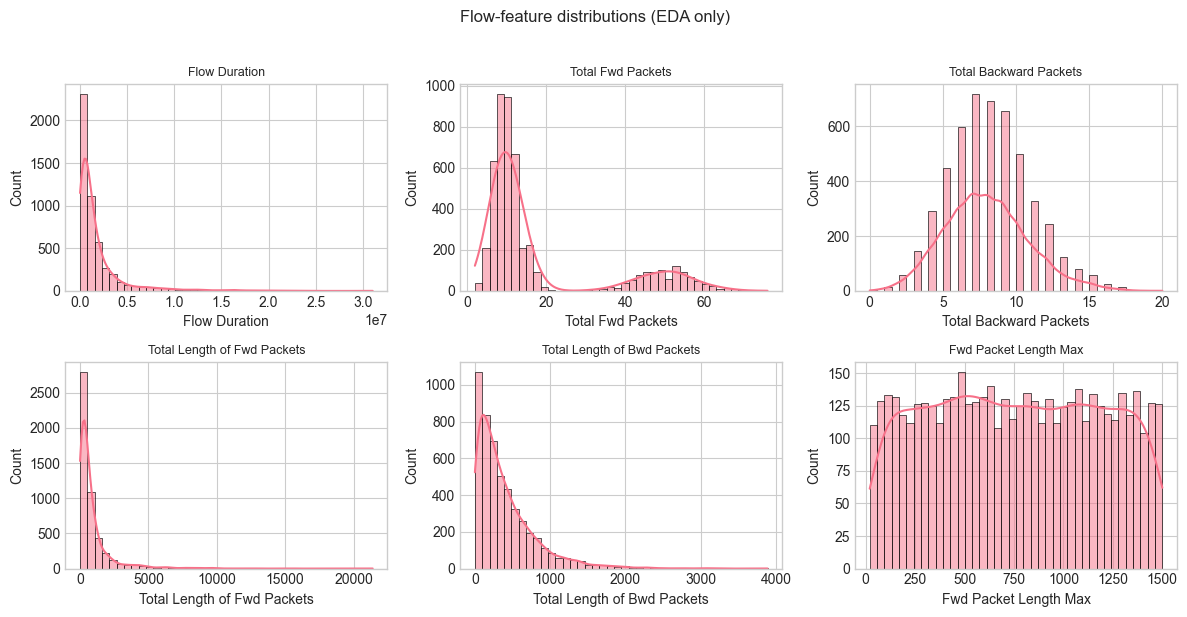

In [5]:
sample_cols = [c for c in numeric.columns if numeric[c].std() > 0][:6]
if sample_cols:
    fig, axes = plt.subplots(2, 3, figsize=(12, 6))
    for ax, col in zip(axes.ravel(), sample_cols):
        sns.histplot(numeric[col].dropna(), bins=40, ax=ax, kde=True)
        ax.set_title(col[:30], fontsize=9)
    plt.suptitle('Flow-feature distributions (EDA only)', y=1.02)
    plt.tight_layout()
    plt.show()

## 6. Day-Based Split Preview

In [6]:
train_day = cfg['data'].get('train_day', 'Monday')
eval_days = cfg.get('evaluation', {}).get('eval_days', ['Friday'])
print(f'Train day : {train_day} (benign flows → spectral windows in nb 02)')
print(f'Eval days : {eval_days}')
print(f'Window label rule: {cfg["evaluation"].get("window_label_rule", "majority")}')

if 'day' in df.columns:
  train_df = df[df['day'] == train_day]
  eval_df = df[df['day'].isin(eval_days)]
  print(f'\nTrain flows ({train_day}): {len(train_df):,}')
  print(f'Eval flows ({eval_days}): {len(eval_df):,}')
  if 'Label' in eval_df.columns:
      print('\nEval-day attack types:')
      print(eval_df['Label'].value_counts().head(8).to_string())

Train day : Monday (benign flows → spectral windows in nb 02)
Eval days : ['Friday']
Window label rule: majority

Train flows (Monday): 5,000
Eval flows (['Friday']): 0

Eval-day attack types:
Series([], )


## 7. Spectral Pipeline Settings (from config.yaml)

In [7]:
spectral = cfg['spectral']
print('input_series      :', spectral.get('input_series'))
print('window_size       :', spectral.get('window_size'))
print('overlap           :', spectral.get('overlap'))
print('multi_scale       :', spectral.get('multi_scale'))
print('delta_features    :', spectral.get('delta_features'))
print('log_transform     :', spectral.get('log_transform_channels'))
print('\nScaling for detection happens on spectral windows in notebook 03.')

input_series      : ['total_bytes', 'total_packets', 'mean_duration']
window_size       : 64
overlap           : 32
multi_scale       : {'enabled': True, 'slow_window_size': 256, 'slow_overlap': 0}
delta_features    : True
log_transform     : ['total_bytes', 'total_packets']

Scaling for detection happens on spectral windows in notebook 03.


## 8. Optional — Raw Feature Scaling (EDA only)

In [8]:
from src.preprocessor import DataPreprocessor, get_feature_columns

feat_cols = get_feature_columns(df)
if feat_cols:
    X = df[feat_cols].apply(pd.to_numeric, errors='coerce').fillna(0).values
    pre = DataPreprocessor()
    X_scaled = pre.fit_transform(X[: min(5000, len(X))], feature_names=feat_cols)
    print(f'Demo-scaled {X_scaled.shape[0]} flows x {X_scaled.shape[1]} features')
    print('(Not saved — spectral features are built in notebook 02)')
else:
    print('No standard feature columns found for scaling demo')

Demo-scaled 5000 flows x 70 features
(Not saved — spectral features are built in notebook 02)
